### Outline on what to do

---

1. Dataset
    - Gunakan UBFC-Phys: memiliki dua kondisi (rest dan arithmetic task)

2. Ekstraksi Sinyal rPPG
    - Gunakan metode video-based rPPG (ICA/POS/CHROM/GREEN/OMIT)
    - Hasilkan estimasi Pulse Rate (HR) per detik

3. Validasi rPPG terhadap Ground Truth
    - Bandingkan HR dari rPPG dengan HR dari PPG (ground truth)

        Hitung:
        - Pearson correlation
        - MAE / RMSE

4. Analisis Perbedaan Kondisi (Rest vs Task)
    - Hitung HR rata-rata saat rest dan task per subjek

        Lakukan:

        - Paired test statistika untuk memastikan apakah peningkatan HR / HRV itu konsisten pada semua subjek

In [1]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable

# List of signals and it's compsition
Rest (Task 1) / Mental Cognitive (Task 3) state:
- POS
- Green
- Chrom
- OMIT
- LGI


In [2]:
def preprocess_ppg(signal, fs = 35):
    """ Computes the Preprocessed PPG Signal, this steps include the following:
        1. Moving Average Smoothing
        2. Bandpass Filtering
        
        Parameters:
        ----------
        signal (numpy array): 
            The PPG Signal to be preprocessed
        fs (float): 
            The Sampling Frequency of the Signal
            
        Returns:
        --------
        numpy array: 
            The Preprocessed PPG Signal
    
    """ 

    # Bandpass filter to isolate the cardiac component (0.4-2.5 Hz)
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs)
    filtered = scipy.signal.filtfilt(b, a, signal)

    # Standarized filtered signal
    filtered = (filtered - np.mean(filtered)) / np.std(filtered)
    
    return filtered

### Extracting the rPPG with the Landmarker (Mental Cognitive State)

---

In [3]:
root_path = "UBFC-Phys"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T3"]

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

face_landmarker_gt_task = []
pos_face_landmarker_rppg_data_task= []
lgi_face_landmarker_rppg_data_task = []
omit_face_landmarker_rppg_data_task = []
green_face_landmarker_rppg_data_task = []
chrom_face_landmarker_rppg_data_task = []

for subject in subjects:
    for task in tasks:
        # Load ground truth data
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        
        # Load rPPG data for each method
        pos_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_POS_rppg.npy")
        pos_data = np.load(pos_file)
        
        lgi_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_LGI_rppg.npy")
        lgi_data = np.load(lgi_file)

        omit_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_OMIT_rppg.npy")
        omit_data = np.load(omit_file)
        
        green_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_GREEN_rppg.npy")
        green_data = np.load(green_file)

        chrom_file = os.path.join(root_path, subject, f"Landmark_{subject}_{task}_CHROM_rppg.npy")
        chrom_data = np.load(chrom_file)
        
        # Preprocess the rPPG signals
        gt_data_preprocessed = preprocess_ppg(gt_data, fs=sample_rate_gt)
        pos_data_preprocessed = preprocess_ppg(pos_data)
        lgi_data_preprocessed = preprocess_ppg(lgi_data)
        omit_data_preprocessed = preprocess_ppg(omit_data)
        green_data_preprocessed = preprocess_ppg(green_data)
        chrom_data_preprocessed = preprocess_ppg(chrom_data)
        
        # Store the data
        face_landmarker_gt_task.append(gt_data_preprocessed)
        pos_face_landmarker_rppg_data_task.append(pos_data_preprocessed)
        lgi_face_landmarker_rppg_data_task.append(lgi_data_preprocessed)
        omit_face_landmarker_rppg_data_task.append(omit_data_preprocessed)
        green_face_landmarker_rppg_data_task.append(green_data_preprocessed)
        chrom_face_landmarker_rppg_data_task.append(chrom_data_preprocessed)


In [4]:
# Print info about the list lengths
print(f"Number of GT arrays: {len(face_landmarker_gt_task)}")
print(f"Number of POS arrays: {len(lgi_face_landmarker_rppg_data_task)}")

# Print shape of some individual arrays
print(f"First GT array shape: {face_landmarker_gt_task[0].shape}")
print(f"First POS array shape: {lgi_face_landmarker_rppg_data_task[0].shape}")

Number of GT arrays: 16
Number of POS arrays: 16
First GT array shape: (11520,)
First POS array shape: (6325,)


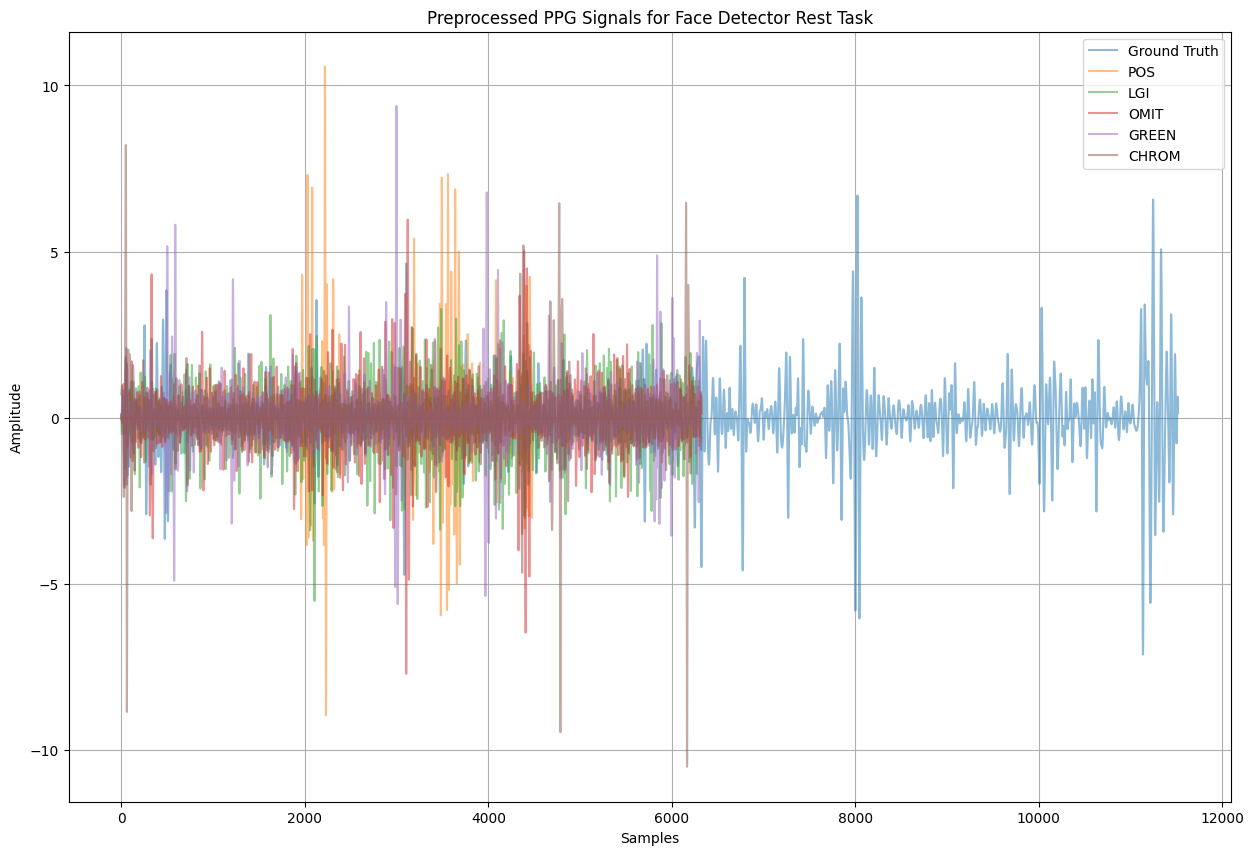

In [5]:
## Plot the Preprocessed Signals
plt.figure(figsize=(15, 10))
plt.plot(face_landmarker_gt_task[15], label='Ground Truth', alpha=0.5)
plt.plot(pos_face_landmarker_rppg_data_task[14], label='POS', alpha=0.5)
plt.plot(lgi_face_landmarker_rppg_data_task[13], label='LGI', alpha=0.5)
plt.plot(omit_face_landmarker_rppg_data_task[12], label='OMIT', alpha=0.5)
plt.plot(green_face_landmarker_rppg_data_task[11], label='GREEN', alpha=0.5)
plt.plot(chrom_face_landmarker_rppg_data_task[10], label='CHROM', alpha=0.5)
plt.title('Preprocessed PPG Signals for Face Detector Rest Task')
plt.xlabel('Samples')
plt.ylabel('Amplitude')
plt.legend()
plt.grid()

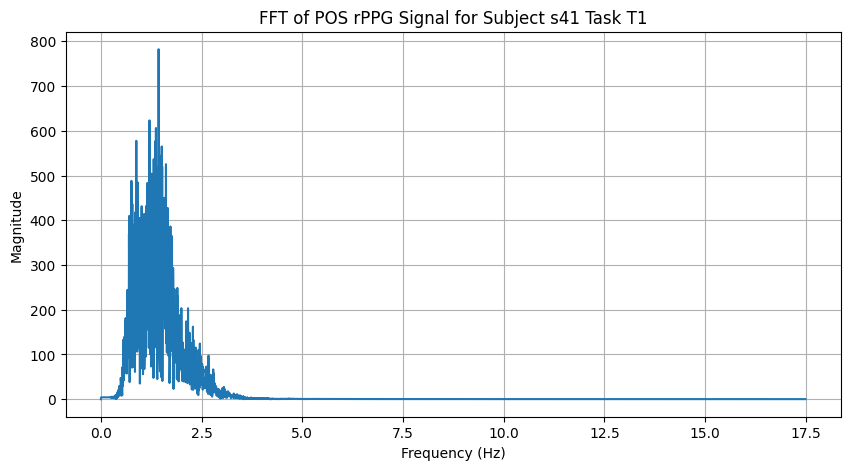

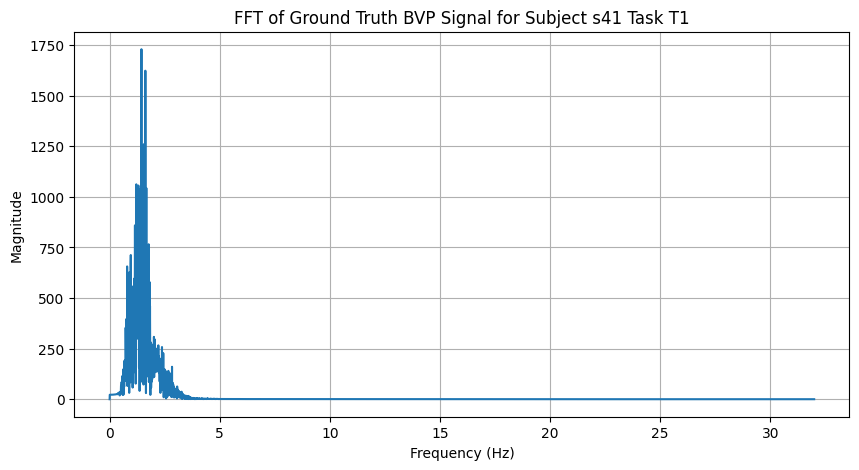

In [6]:
## Check the FFT of any signals if already being processed
def plot_fft(signal, fs, title):
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    fft_values = np.abs(np.fft.fft(signal))
    
    plt.figure(figsize=(10, 5))
    plt.plot(freqs[:len(freqs)//2], fft_values[:len(fft_values)//2])
    plt.title(title)
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude')
    plt.grid()
    plt.show()

# Example of plotting FFT for one of the rPPG methods
plot_fft(lgi_face_landmarker_rppg_data_task[5], sample_rate_video, 'FFT of POS rPPG Signal for Subject s41 Task T1')
# Example of plotting FFT for ground truth BVP
plot_fft(face_landmarker_gt_task[5], sample_rate_gt, 'FFT of Ground Truth BVP Signal for Subject s41 Task T1')

## Calculate the HR

---

In [7]:
def calculate_hr(gt, rppg):
    """ Calculate the Heart Rate from the Ground Truth and rPPG Signals
    
        Parameters:
        ----------
        gt (numpy array): 
            The Ground Truth BVP Signal
        rppg (numpy array): 
            The rPPG Signal
            
        Returns:
        --------
        float: 
            The calculated Heart Rate in beats per minute (BPM)
    """

    # Calculate the peaks in the ground truth signal
    gt_peaks, _ = scipy.signal.find_peaks(gt, prominence=0.5)  
    gt_hr = int(np.mean(60 / (np.diff(gt_peaks) / sample_rate_gt)))

    # Calculate the peaks in the rPPG signal
    rppg_peaks, _ = scipy.signal.find_peaks(rppg, prominence=0.5)  
    rppg_hr = int(np.mean(60 / (np.diff(rppg_peaks) / sample_rate_video)))

    return gt_hr, rppg_hr, gt_peaks, rppg_peaks



### Ekstraksi HR dari setiap metode

In [8]:
rppg = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}

for i in range(len(face_landmarker_gt_task)):
    gt_hr, pos_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], pos_face_landmarker_rppg_data_task[i])
    gt_hr, lgi_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], lgi_face_landmarker_rppg_data_task[i])
    gt_hr, omit_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], omit_face_landmarker_rppg_data_task[i])
    gt_hr, green_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], green_face_landmarker_rppg_data_task[i])
    gt_hr, chrom_hr, _, _ = calculate_hr(face_landmarker_gt_task[i], chrom_face_landmarker_rppg_data_task[i])

    # Append the calculated heart rates to the rPPG dictionary
    rppg["POS"].append(pos_hr)
    rppg["LGI"].append(lgi_hr)
    rppg["OMIT"].append(omit_hr)
    rppg["GREEN"].append(green_hr)
    rppg["CHROM"].append(chrom_hr)

# Create a table to display the results
df = pd.DataFrame({
    "Subject": [f"s{i+41}" for i in range(len(face_landmarker_gt_task))],
    "GT HR (BPM)": [calculate_hr(face_landmarker_gt_task[i], face_landmarker_gt_task[i])[0] for i in range(len(face_landmarker_gt_task))],
    "POS HR (BPM)": rppg["POS"],
    "LGI HR (BPM)": rppg["LGI"],
    "OMIT HR (BPM)": rppg["OMIT"],
    "GREEN HR (BPM)": rppg["GREEN"],
    "CHROM HR (BPM)": rppg["CHROM"]
})

print("\nHeart Rate Results:")
print(df)




Heart Rate Results:
   Subject  GT HR (BPM)  POS HR (BPM)  LGI HR (BPM)  OMIT HR (BPM)  \
0      s41           82            98            97             95   
1      s42           88            91            77             79   
2      s43           88            85            84             80   
3      s44           68            72            70             72   
4      s45           85            79            69             70   
5      s46           90            86            87             86   
6      s47           87            77            84             82   
7      s48           81            77            76             76   
8      s49           78            79            77             76   
9      s50          105            97            98             98   
10     s51           74            78            76             76   
11     s52           80            86            86             86   
12     s53           74            82            77             77   

In [9]:
# Compute the MAE 
from sklearn.metrics import mean_absolute_error
mae_pos = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(rppg["POS"]))
mae_lgi = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(rppg["LGI"]))
mae_omit = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(rppg["OMIT"]))
mae_green = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(rppg["GREEN"]))
mae_chrom = mean_absolute_error(np.array(df["GT HR (BPM)"]), np.array(rppg["CHROM"]))

# Create a table to display the MAE results
df_mae = pd.DataFrame({
    "Method": ["POS", "LGI", "OMIT", "GREEN", "CHROM"],
    "MAE (BPM)": [mae_pos, mae_lgi, mae_omit, mae_green, mae_chrom]
})
print("\nMean Absolute Error (MAE) Results:")
print(df_mae)


Mean Absolute Error (MAE) Results:
  Method  MAE (BPM)
0    POS     5.3750
1    LGI     5.3750
2   OMIT     5.8125
3  GREEN    16.0625
4  CHROM     4.1875


In [10]:
## Calculate the RMSE 
from sklearn.metrics import root_mean_squared_error
rmse_pos = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(rppg["POS"]))
rmse_lgi = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(rppg["LGI"]))
rmse_omit = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(rppg["OMIT"]))
rmse_green = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(rppg["GREEN"]))
rmse_chrom = root_mean_squared_error(np.array(df["GT HR (BPM)"]), np.array(rppg["CHROM"]))

# Create a table to display the RMSE results
df_rmse = pd.DataFrame({
    "Method": ["POS", "LGI", "OMIT", "GREEN", "CHROM"],
    "RMSE (BPM)": [rmse_pos, rmse_lgi, rmse_omit, rmse_green, rmse_chrom]
})
print("\nRoot Mean Squared Error (RMSE) Results:")
print(df_rmse)


Root Mean Squared Error (RMSE) Results:
  Method  RMSE (BPM)
0    POS    6.519202
1    LGI    7.062223
2   OMIT    6.896557
3  GREEN   18.253424
4  CHROM    5.595757


## Compute the HRV Metrics
HRV sendiri merupakan bagian detail dari denyut nadi / detak jantung, yang menunjukan pola variabilitas antara detak jantung.

Compute the correlation between the rPPG and PPG on several metrics and see which one is good

The HRV Metrics that we're going to use, all of the calculation is done under the
| **Domain**     | **HRV Feature** | **Unit** | **Description**                                                                 |
|----------------|------------------|----------|----------------------------------------------------------------------------------|
| **Time**       | MeanNN           | ms       | Mean NN interval (Time it takes between each peak to peak) in milis              |
|                | SDNN             | ms       | Standard deviation of the RR intervals                                           |
|                | RMSSD            | ms       | Root mean square of successive RR interval differences                           |
|                | PR               | bpm      | Mean heart rate                                                                  |
| **Frequency**  | LF               | ms²      | Power of low frequency band (0.04–0.15 Hz)                                       |
|                | HF               | ms²      | Power of high frequency band (0.15–0.4 Hz)                                       |
|                | LF/HF            | -        | Ratio of LF to HF                                                                |


In [11]:
# Compute the HRV metrics
gt_metrics = {
    'MeanNN': [],
    'SDNN': [],
    'RMSSD': [],
    'LF': [],
    'HF': [],
    'LF_HF': [],
    'PR' : [],
}

rppg_method = {
    "POS" : [],
    "LGI" : [],
    "OMIT" : [],
    "GREEN" : [],
    "CHROM" : []
}
 

for i in range(len(face_landmarker_gt_task)): # 16 Subjects
    gt_hr, _, gt_peaks, _ = calculate_hr(face_landmarker_gt_task[i], pos_face_landmarker_rppg_data_task[i])
    gt_hrv = nk.hrv(gt_peaks, sampling_rate=sample_rate_gt)
    gt_metrics['PR'].append(gt_hr)
    gt_metrics['MeanNN'].append(gt_hrv['HRV_MeanNN'][0])
    gt_metrics['SDNN'].append(gt_hrv['HRV_SDNN'][0])
    gt_metrics['RMSSD'].append(gt_hrv['HRV_RMSSD'][0])
    gt_metrics['LF'].append(gt_hrv['HRV_LF'][0])
    gt_metrics['HF'].append(gt_hrv['HRV_HF'][0])
    gt_metrics['LF_HF'].append(gt_hrv['HRV_LFHF'][0])

    _, pos_hr, _, pos_peaks = calculate_hr(face_landmarker_gt_task[i], pos_face_landmarker_rppg_data_task[i])
    pos_hrv = nk.hrv(pos_peaks, sampling_rate=sample_rate_video)
    rppg_method['POS'].append({
        'PR': pos_hr,
        'MeanNN': pos_hrv['HRV_MeanNN'][0],
        'SDNN': pos_hrv['HRV_SDNN'][0],
        'RMSSD': pos_hrv['HRV_RMSSD'][0],
        'LF': pos_hrv['HRV_LF'][0],
        'HF': pos_hrv['HRV_HF'][0],
        'LF_HF': pos_hrv['HRV_LFHF'][0]
    })

    _, lgi_hr, _, lgi_peaks = calculate_hr(face_landmarker_gt_task[i], lgi_face_landmarker_rppg_data_task[i])
    lgi_hrv = nk.hrv(lgi_peaks, sampling_rate=sample_rate_video)
    rppg_method['LGI'].append({
        'PR': lgi_hr,
        'MeanNN': lgi_hrv['HRV_MeanNN'][0],
        'SDNN': lgi_hrv['HRV_SDNN'][0],
        'RMSSD': lgi_hrv['HRV_RMSSD'][0],
        'LF': lgi_hrv['HRV_LF'][0],
        'HF': lgi_hrv['HRV_HF'][0],
        'LF_HF': lgi_hrv['HRV_LFHF'][0]
    })

    _, omit_hr, _, omit_peaks = calculate_hr(face_landmarker_gt_task[i], omit_face_landmarker_rppg_data_task[i])
    omit_hrv = nk.hrv(omit_peaks, sampling_rate=sample_rate_video)
    rppg_method['OMIT'].append({
        'PR': omit_hr,  
        'MeanNN': omit_hrv['HRV_MeanNN'][0],
        'SDNN': omit_hrv['HRV_SDNN'][0],
        'RMSSD': omit_hrv['HRV_RMSSD'][0],
        'LF': omit_hrv['HRV_LF'][0],
        'HF': omit_hrv['HRV_HF'][0],
        'LF_HF': omit_hrv['HRV_LFHF'][0]
    })

    _, green_hr, _, green_peaks = calculate_hr(face_landmarker_gt_task[i], green_face_landmarker_rppg_data_task[i])
    green_hrv = nk.hrv(green_peaks, sampling_rate=sample_rate_video)
    rppg_method['GREEN'].append({
        'PR': green_hr,
        'MeanNN': green_hrv['HRV_MeanNN'][0],
        'SDNN': green_hrv['HRV_SDNN'][0],
        'RMSSD': green_hrv['HRV_RMSSD'][0],
        'LF': green_hrv['HRV_LF'][0],
        'HF': green_hrv['HRV_HF'][0],
        'LF_HF': green_hrv['HRV_LFHF'][0]
    })

    _, chrom_hr, _, chrom_peaks = calculate_hr(face_landmarker_gt_task[i], chrom_face_landmarker_rppg_data_task[i])
    chrom_hrv = nk.hrv(chrom_peaks, sampling_rate=sample_rate_video)
    rppg_method['CHROM'].append({
        'PR': chrom_hr,
        'MeanNN': chrom_hrv['HRV_MeanNN'][0],
        'SDNN': chrom_hrv['HRV_SDNN'][0],
        'RMSSD': chrom_hrv['HRV_RMSSD'][0],
        'LF': chrom_hrv['HRV_LF'][0],
        'HF': chrom_hrv['HRV_HF'][0],
        'LF_HF': chrom_hrv['HRV_LFHF'][0]
    })

print("\nGround Truth HRV Metrics:")
gt_metrics_df = pd.DataFrame(gt_metrics)
print(gt_metrics_df)

# Print the POS
print("\nPOS rPPG HRV Metrics:")
pos_metrics_df = pd.DataFrame(rppg_method['POS'])
print(pos_metrics_df)

# Print the LGI
print("\nLGI rPPG HRV Metrics:")
lgi_metrics_df = pd.DataFrame(rppg_method['LGI'])
print(lgi_metrics_df)

# Print the OMIT
print("\nOMIT rPPG HRV Metrics:")
omit_metrics_df = pd.DataFrame(rppg_method['OMIT'])
print(omit_metrics_df)

# Print the GREEN
print("\nGREEN rPPG HRV Metrics:")
green_metrics_df = pd.DataFrame(rppg_method['GREEN'])
print(green_metrics_df)

# Print the CHROM
print("\nCHROM rPPG HRV Metrics:")
chrom_metrics_df = pd.DataFrame(rppg_method['CHROM'])
print(chrom_metrics_df)



c:\Users\ACER\miniconda3\envs\phyrexian\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\ACER\miniconda3\envs\phyrexian\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(
c:\Users\ACER\miniconda3\envs\phyrexian\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum


Ground Truth HRV Metrics:
        MeanNN         SDNN        RMSSD        LF        HF      LF_HF   PR
0   801.409040   265.004259   348.990577  0.032640  0.063213   0.516344   82
1   719.001004   185.785635   235.018857  0.041974  0.092256   0.454970   88
2   710.097112   178.535776   243.098087  0.044222  0.036992   1.195454   88
3   929.687500   257.247293   340.174693  0.037381  0.039978   0.935048   68
4   721.648185   115.709376   155.701847  0.050076  0.042768   1.170866   85
5   674.577068   104.503390   116.235322  0.041377  0.036220   1.142381   90
6   800.228311   427.244165   566.823661  0.025023  0.018846   1.327709   87
7   976.690574  1009.055077  1452.684136  0.035317  0.002897  12.191685   81
8   882.116337   369.347590   512.235865  0.026746  0.076947   0.347594   78
9   579.540858    86.774914    97.878197  0.052749  0.033090   1.594140  105
10  825.820853   139.565198   177.981027  0.062535  0.082799   0.755265   74
11  804.161996   237.575505   311.516611  0.04107

c:\Users\ACER\miniconda3\envs\phyrexian\Lib\site-packages\neurokit2\hrv\hrv_nonlinear.py:536: NeuroKitWarning: DFA_alpha2 related indices will not be calculated. The maximum duration of the windows provided for the long-term correlation is smaller than the minimum duration of windows. Refer to the `scale` argument in `nk.fractal_dfa()` for more information.
  warn(


## Compute the Correlation of the between the rPPG and PPG for HR and HRV

In [12]:
# Pearson Correlation between rPPG and PPG on several metrics
def compute_correlation(gt_metrics, rppg_metrics):
    """ Computes the Pearson correlation between ground truth metrics and rPPG metrics
    
        Parameters:
        ----------
        gt_metrics (dict): 
            The Ground Truth HRV Metrics
        rppg_metrics (dict): 
            The rPPG HRV Metrics
            
        Returns:
        --------
        dict: 
            A dictionary containing the Pearson correlation coefficients for each metric
    """
    correlations = {}
    for metric in gt_metrics.keys():
        correlations[metric] = scipy.stats.pearsonr(gt_metrics[metric], [r[metric] for r in rppg_metrics])[0]
    return correlations

# Compute the Pearson correlation for each rPPG method
pearson_correlations = {}
for method in rppg_method.keys():
    pearson_correlations[method] = compute_correlation(gt_metrics, rppg_method[method])
# Create a DataFrame to display the Pearson correlation results
pearson_correlation_df = pd.DataFrame(pearson_correlations).T
pearson_correlation_df.columns = ['MeanNN', 'SDNN', 'RMSSD', 'LF', 'HF', 'LF_HF', 'PR']
print("\nPearson Correlation between Ground Truth and rPPG Metrics:")
print(pearson_correlation_df)



Pearson Correlation between Ground Truth and rPPG Metrics:
         MeanNN      SDNN     RMSSD        LF        HF     LF_HF        PR
POS    0.309393 -0.023075 -0.042103  0.370493  0.360310  0.048099  0.670808
LGI    0.038444 -0.068385 -0.062577  0.373149  0.311212 -0.072994  0.660614
OMIT   0.115034 -0.015485 -0.018934  0.201963  0.283535  0.149882  0.667468
GREEN  0.121620  0.030804  0.020886  0.434548  0.054669 -0.139022  0.420469
CHROM  0.073408 -0.012515 -0.017848 -0.109392  0.170062 -0.096022  0.779544
